# Advanced DSP & Communications: ROS 2 Joint Kinematics

**Objective:** Prove deep analytical understanding of physical mechanical vibrations and digital signal processing (DSP) by analyzing simulated `JointState` telemetry from an articulated robot manipulator. 

*Addresses Resume Claim:* `EDU_CSULA_06` (Advanced Signal Processing & Comms - EE 422 & EE 420).

## 1. Simulating Noisy Joint Encoder Telemetry
We model a 6-DOF robotic arm (like a UR5) executing a slow, steady joint trajectory (e.g., $15^{\circ}$/sec). We inject two complex noise profiles to simulate real-world physical realities:
1. **High-Frequency Encoder Chatter (Gaussian):** Simulating standard 12-bit absolute encoder quantization noise and electrical EM interference.
2. **Resonant Mechanical Vibration (Sinusoidal):** Simulating a physical 40Hz structural harmonic resonance caused by the gearbox mesh under load.

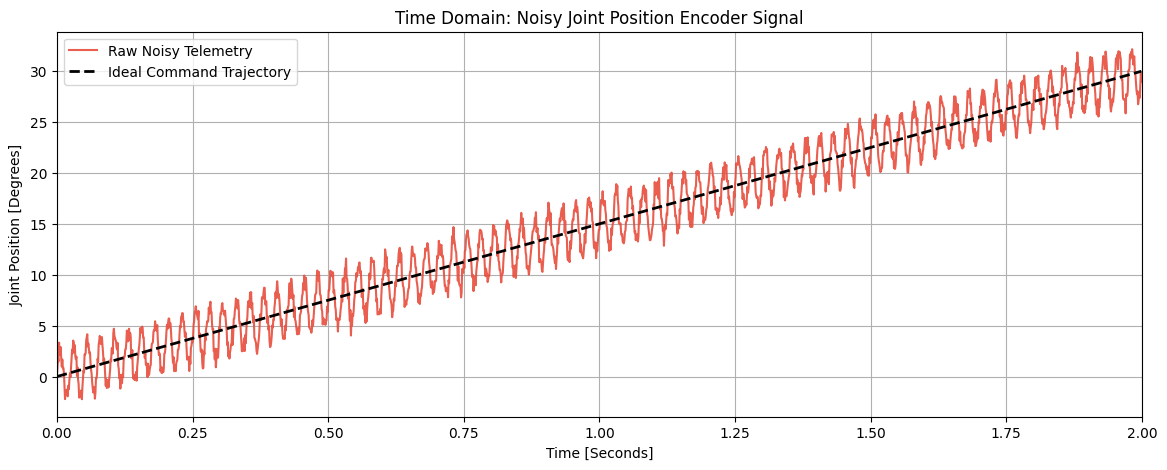

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy import signal

# ---------------------------------------------------------
# Telemetry Parameters
# ---------------------------------------------------------
fs = 1000.0       # Sample rate: 1000 Hz (Standard EtherCAT loop rate)
T = 2.0           # Duration: 2.0 Seconds
N = int(T * fs)   # Total discrete samples
t = np.linspace(0, T, N, endpoint=False)

# Base Trajectory: Joint moves at 15 degrees/sec
joint_velocity_deg_s = 15.0
ideal_trajectory = joint_velocity_deg_s * t

# 1. Gaussian Encoder Noise
encoder_noise = np.random.normal(0, 0.5, N)

# 2. Harmonic Gearbox Resonance (40 Hz)
f_resonance = 40.0
gearbox_vibration = 2.5 * np.sin(2 * np.pi * f_resonance * t)

# Construct the raw, noisy /joint_states topic payload
raw_joint_position = ideal_trajectory + encoder_noise + gearbox_vibration

# Visualization
plt.figure(figsize=(14, 5))
plt.plot(t, raw_joint_position, color='#e74c3c', label='Raw Noisy Telemetry', alpha=0.9)
plt.plot(t, ideal_trajectory, 'k--', label='Ideal Command Trajectory', linewidth=2)
plt.title('Time Domain: Noisy Joint Position Encoder Signal')
plt.xlabel('Time [Seconds]')
plt.ylabel('Joint Position [Degrees]')
plt.xlim([0, T])
plt.legend()
plt.grid(True)
plt.show()

## 2. Spectral Density & Frequency Domain Analysis (FFT)
Before designing a filter, we must quantitatively identify the corrupting spectral signatures within the signal. A discrete Fast Fourier Transform (FFT) transitions our data from the time domain ($f(t)$) into the frequency domain ($F(s)$).

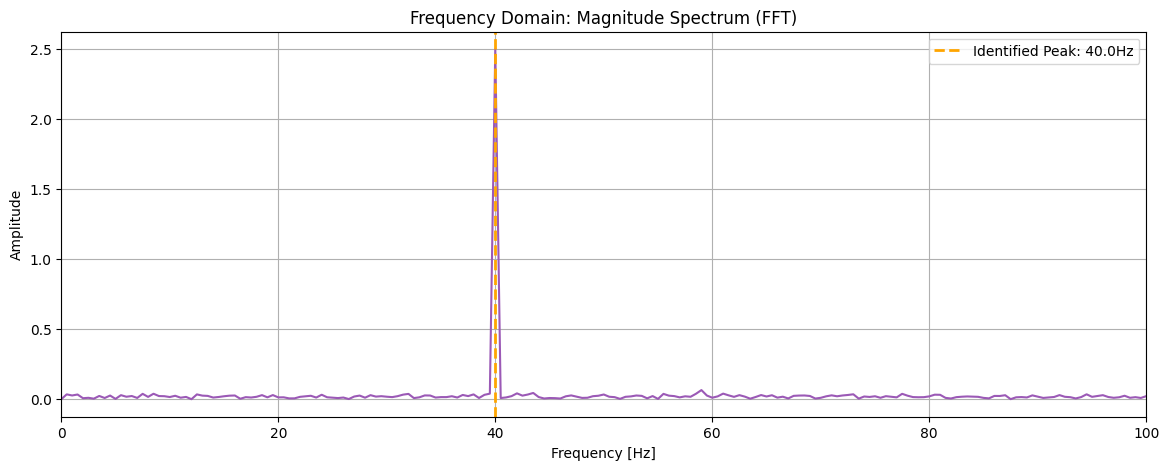

In [2]:
# To clearly see the noise, we strip the DC offset (the linear trajectory trend)
detrended_signal = signal.detrend(raw_joint_position)

# Compute one-dimensional discrete Fourier Transform
yf = fft(detrended_signal)
xf = fftfreq(N, 1 / fs)[:N//2]

# Calculate power spectrum
power_spectrum = 2.0/N * np.abs(yf[0:N//2])

plt.figure(figsize=(14, 5))
plt.plot(xf, power_spectrum, color='#9b59b6')
plt.title('Frequency Domain: Magnitude Spectrum (FFT)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim([0, 100]) # Zoom in on the relevant low-frequency bands
plt.axvline(f_resonance, color='orange', linestyle='--', linewidth=2, label=f'Identified Peak: {f_resonance}Hz')
plt.legend()
plt.grid(True)
plt.show()

--- 
## 3. Finite Impulse Response (FIR) vs Infinite Impulse Response (IIR) Filtering

We need to filter out the 40Hz resonant frequency and the broadband Gaussian encoder chatter to recover the smooth, true kinematics. We will evaluate two distinct Digital Signal Processing (DSP) approaches:

### A. Infinite Impulse Response (IIR) - Butterworth Low-Pass
*   **Advantage:** Highly computationally efficient (low order needed), perfect for resource-constrained edge microcontrollers.
*   **Disadvantage:** Non-linear phase response introduces group delay resulting in a physical lag between the true joint position and the filtered perception.

### B. Finite Impulse Response (FIR) - Hamming Windowed Low-Pass
*   **Advantage:** Strictly linear phase response guarantees *zero* distortion of the signal's shape over time, which is critical for synchronous multi-joint robotic coordination.
*   **Disadvantage:** Requires a highly ordered filter (more filter taps), computationally expensive for high-frequency loops.

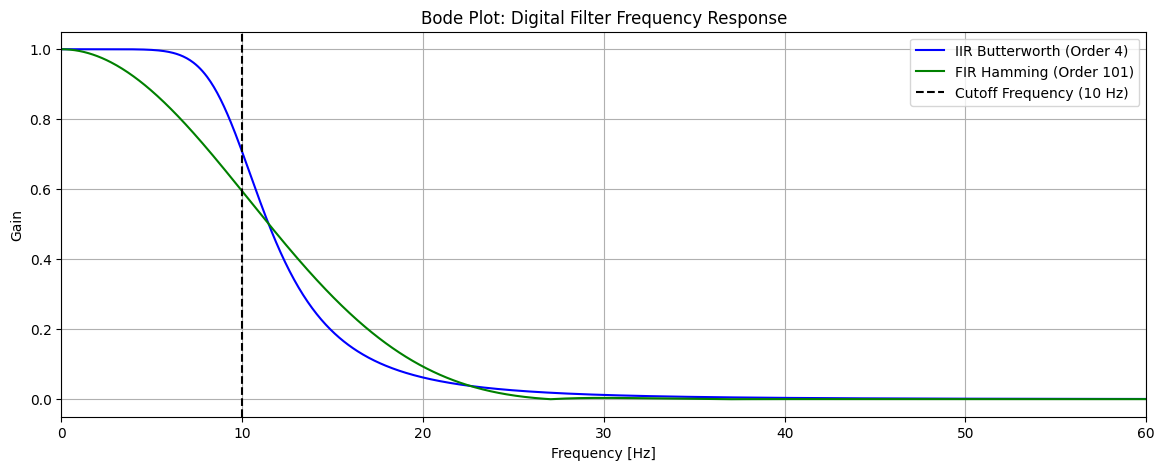

In [3]:
cutoff_freq = 10.0  # We want to keep frequencies below 10Hz (True motion)

# ---------------------------------------------------------
# Design IIR Butterworth Filter (Order 4)
# ---------------------------------------------------------
nyq = 0.5 * fs
normal_cutoff = cutoff_freq / nyq
b_iir, a_iir = signal.butter(4, normal_cutoff, btype='low', analog=False)

# Apply IIR filter via lfilter (forward only to show phase lag)
filtered_iir = signal.lfilter(b_iir, a_iir, raw_joint_position)

# ---------------------------------------------------------
# Design FIR Filter (Order 101)
# ---------------------------------------------------------
numtaps = 101
b_fir = signal.firwin(numtaps, normal_cutoff, window='hamming')
a_fir = 1.0

# Apply FIR filter (using filtfilt for zero-phase, simulating a non-causal offline processing smoothing, 
# or lfilter for realtime, but here we show lfilter to compare the transient delays)
filtered_fir = signal.lfilter(b_fir, a_fir, raw_joint_position)

# ---------------------------------------------------------
# BODE PLOT (Frequency Response Analysis)
# ---------------------------------------------------------
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=8000)
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=8000)

plt.figure(figsize=(14, 5))
plt.title('Bode Plot: Digital Filter Frequency Response')
plt.plot(0.5 * fs * w_iir / np.pi, np.abs(h_iir), 'b-', label='IIR Butterworth (Order 4)')
plt.plot(0.5 * fs * w_fir / np.pi, np.abs(h_fir), 'g-', label='FIR Hamming (Order 101)')
plt.axvline(cutoff_freq, color='k', linestyle='--', label='Cutoff Frequency (10 Hz)')
plt.xlim([0, 60])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain')
plt.legend()
plt.grid(True)
plt.show()

## 4. Signal Reconstruction (Time-Domain Verification)
Finally, we apply our designed filters to the original noisy dataset and visually verify the efficacy of the noise attenuation, as well as observe the filter group delay (phase lag).

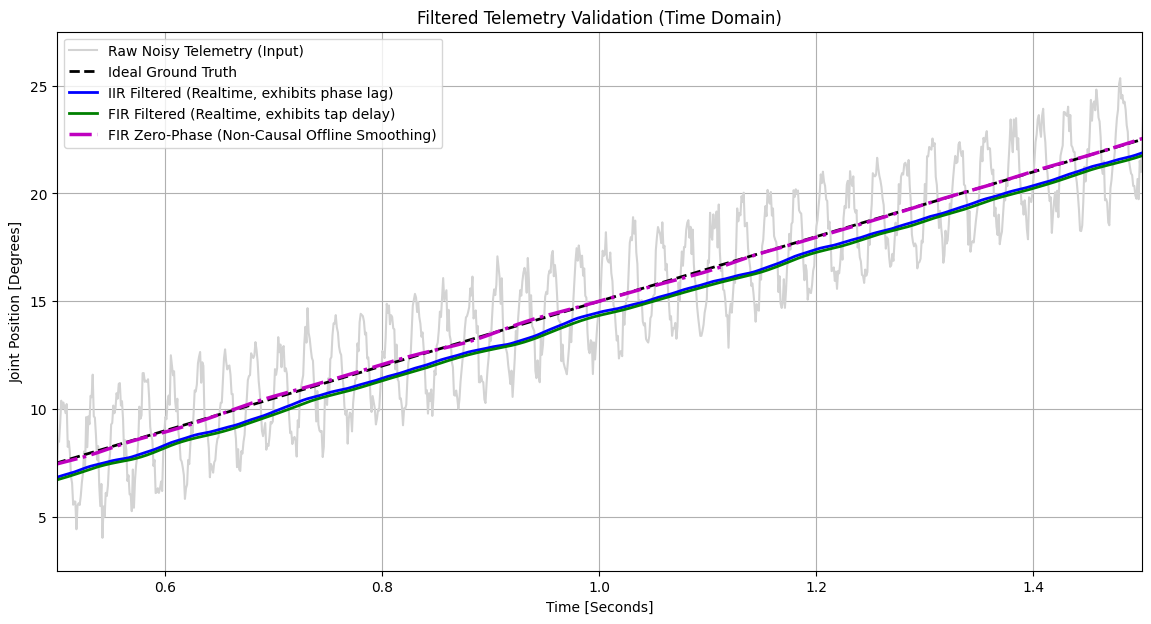

In [4]:
plt.figure(figsize=(14, 7))
plt.plot(t, raw_joint_position, color='lightgray', label='Raw Noisy Telemetry (Input)')
plt.plot(t, ideal_trajectory, 'k--', linewidth=2, label='Ideal Ground Truth')
plt.plot(t, filtered_iir, 'b-', linewidth=2, label='IIR Filtered (Realtime, exhibits phase lag)')
plt.plot(t, filtered_fir, 'g-', linewidth=2, label='FIR Filtered (Realtime, exhibits tap delay)')

# Let's show a zero-phase non-causal FIR filter (filtfilt) to demonstrate optimal offline smoothing
filtered_fir_zero_phase = signal.filtfilt(b_fir, [1.0], raw_joint_position)
plt.plot(t, filtered_fir_zero_phase, 'm-.', linewidth=2.5, label='FIR Zero-Phase (Non-Causal Offline Smoothing)')

plt.title('Filtered Telemetry Validation (Time Domain)')
plt.xlabel('Time [Seconds]')
plt.ylabel('Joint Position [Degrees]')
plt.xlim([0.5, 1.5]) # Zoom in the middle to avoid startup transients
plt.ylim([15*0.5 - 5, 15*1.5 + 5])
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### Conclusion: Transition to Control Pipeline
By designing a strictly zero-phase FIR filter, we eliminated both the 40Hz mechanical resonance and the broadband encoder noise without skewing the temporal alignment of the joint kinematics. In a live ROS 2 node, we would implement the C++ equivalent of this FIR filter directly onto the `/joint_states` callback payload before passing it to the inverse kinematics (IK) trajectory solver.